In [ ]:
import sys
import os
import scMPRAforge as scm
import pandas as pd
import numpy as np

#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

2025-08-18 17:26:45.818679: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-18 17:26:45.822876: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-08-18 17:26:45.822895: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [1]:
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(memory_limit='8GB')
client=Client(cluster)

In [2]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v3"
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
primordial=scm.ortho.load(client,path,name)

In [3]:
import seaborn as sns

In [12]:
scm.SHENDURE_BOUNDS#.cells_per_cell_type

Bounds(metadata=None, min_mpra_umi=0.0034641979561541277, max_mpra_umi=369.88473782763344, by_cre_theta=0.62110305, by_cell_type_theta=0.35434753, by_cre_zi=0.39563528657381514, by_cell_type_zi=0.022971882287718185, num_cres=208, cells_per_cell_type=cell_type
Cardiomyocytes              680
EpiblastPrimitiveStreak    3445
ExEndodermParietal         4644
ExEndodermVisceral         3238
Haematoendothelial         1079
Mesoderm                   7427
NeuroectodermBrain         7750
NeuroectodermRostral       1757
SurfaceEctoderm            5168
reference                  8201
Name: cells_per_cell_type, dtype: int64, transfection_nb_mu=18.010555670792133, transfection_nb_alpha=0.5705626300443596)

Here's an example of creating an artificial experiment.

In [9]:
#first, we define the new parameters we want to assign to this object.
new_cell_number=pd.Series({"reference":1000,"blood":2000,"neuron":1000})
new_MOI=30
new_min=0
new_max=200
new_zi=0.05

In [10]:
new_cell_number

reference    1000
blood        2000
neuron       1000
dtype: int64

In [19]:
artificial_bounds=scm.SHENDURE_BOUNDS.copy()
artificial_bounds.get_effective_moi()

18.010555670792133

In [22]:
artificial_bounds.set_effective_moi(100)

In [17]:
np.linspace(0,1,16)

array([0.        , 0.06666667, 0.13333333, 0.2       , 0.26666667,
       0.33333333, 0.4       , 0.46666667, 0.53333333, 0.6       ,
       0.66666667, 0.73333333, 0.8       , 0.86666667, 0.93333333,
       1.        ])

In [ ]:
def comprehensive_spread():
    #like simple_spread, but creates a CRE for 
    pass

from typing import List

def simple_spread(cell_types:List[str],min:int,max:int,fineness:int=10):
    """
    Create a ground truth dataframe tiling all cell-types.
    with synthetic CREs at a variety of strengths.

    Returns a tuple of (,None) 
    (none will be replaced by hypothesis object)

    Useful for simulation and power calculations.
    (see readme for ground truth dataframe specification)

    min, max are the min & max MPRA UMI / cell values.

    
    
    Also returns a hypothesis object (UNIMPLEMENTED)
    This has the cartesian product of CREs.
    In general, same CRE name 
    """
  
    
    #to generally tile the space
    even_tiling=np.linspace(start=min, stop=max, num=fineness)
    
    even_names=["reference"]+[f"CRE_even_{i}" for i in range(1,len(even_tiling))]
    even_df=pd.DataFrame({"cre_id":even_names,"true_mean":even_tiling})
    #duplicate df for each cell-type
    even_df=pd.concat([even_df]*len(cell_types))
    even_df["cell_type"]=np.repeat(cell_types,len(even_tiling))
    
    #to create a large number of low-expression CREs
    fractional_tiling=1/(2**np.linspace(start=1,stop=fineness,num=fineness))*(max-min)+min
    fractional_tiling_names=[f"CRE_fractional_{i}" for i in range(0,len(fractional_tiling))]
    fractional_tiling_df=pd.DataFrame({"cre_id":fractional_tiling_names,"true_mean":fractional_tiling})
    #duplicate df for each cell-type
    fractional_tiling_df=pd.concat([fractional_tiling_df]*len(cell_types))
    fractional_tiling_df["cell_type"]=np.repeat(cell_types,len(fractional_tiling))
    

    #Then we create some "cell-type-specific CREs". 
    #these are simply "high in one cell-type and low in every other".
    #where "high" is a value from even tiling+1. 
    #and "low" =ln(high)

    #cell-type specific
    ct_specific=even_df
    ct_specific=ct_specific.rename({"true_mean":"high","cell_type":"expressed_cell_type"},axis=1)
    ct_specific["high"]=ct_specific["high"]+1
    ct_specific["low"]=np.log(ct_specific["high"])

    #ok, so we've created a high and low value for each CRE. 
    #"expressed_cell_type" will be highest cell-type
    #so let's rename accordingly
    ct_specific["cre_id"]=\
        ct_specific["cre_id"].astype(str)+\
        "_high_in_"+\
        ct_specific["expressed_cell_type"].astype(str)
    
    #let's repeat the DF across all cell-types
    #every CRE in every cell-type, after all...
    ct_specific=pd.concat([ct_specific]*len(cell_types))
    ct_specific["cell_type"]=np.repeat(cell_types,int(len(ct_specific)/len(cell_types)))
    #now let's assign values...
    ct_specific=ct_specific.assign(
        true_mean=np.where(ct_specific["cell_type"]==ct_specific["expressed_cell_type"],
                           ct_specific["high"],
                           ct_specific["low"])
    )
    #drop extranious columns
    ct_specific=ct_specific[["cre_id","cell_type","true_mean"]]

    final_ground_truth=pd.concat([even_df,fractional_tiling_df,ct_specific])
    
    hypothesis_set=None
    return (final_ground_truth,hypothesis_set)
    

x=simple_spread(new_cell_number.keys(),1,450)
x.to_csv("test.csv")#[0]
x

,cre_id,high,expressed_cell_type,low,cell_type,true_mean
0,reference_high_in_reference,2.000000,reference,0.693147,reference,2.000000
1,CRE_even_1_high_in_reference,51.888889,reference,3.949105,reference,51.888889
2,CRE_even_2_high_in_reference,101.777778,reference,4.622792,reference,101.777778
3,CRE_even_3_high_in_reference,151.666667,reference,5.021685,reference,151.666667
4,CRE_even_4_high_in_reference,201.555556,reference,5.306065,reference,201.555556
...,...,...,...,...,...,...
5,CRE_even_5_high_in_neuron,251.444444,neuron,5.527222,neuron,251.444444
6,CRE_even_6_high_in_neuron,301.333333,neuron,5.708217,neuron,301.333333
7,CRE_even_7_high_in_neuron,351.222222,neuron,5.861419,neuron,351.222222
8,CRE_even_8_high_in_neuron,401.111111,neuron,5.994238,neuron,401.111111


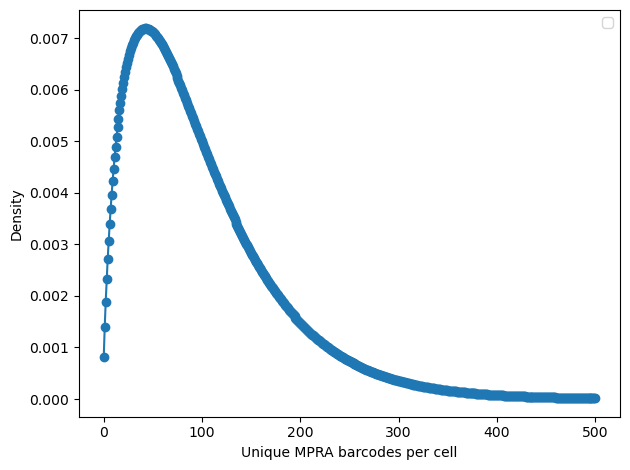

In [23]:
artificial_bounds.plot_transfection()

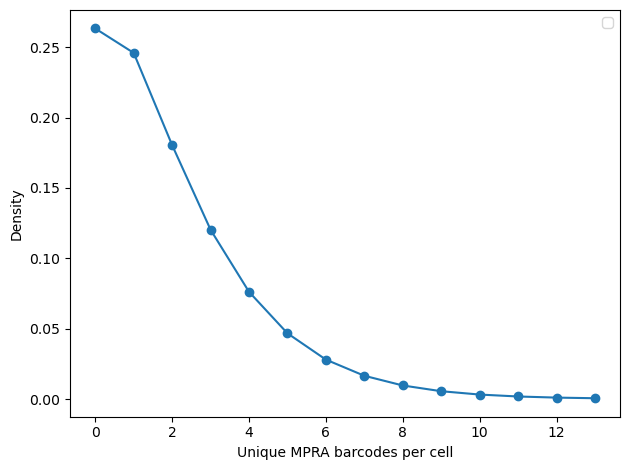

In [25]:
lame_experiment=scm.SHENDURE_BOUNDS.copy()
lame_experiment.set_effective_moi(2)
lame_experiment.plot_transfection()

In [ ]:
def description_from_bounds(inp:scm.Bounds,
                            nb_dataframe):
    """
    Returns a primordial description dask dataframe from bounds
    and nb_dataframe.
    
    Only type implemented for now is `simple_spread`
    - tiles CREs over the bounds range 
    other will be 
    - `override` : allowing you to specify exactly what nb param
    """

    #known before you start or "to be optimized":
    #  cells per cell-type is a fixed parameter
    #  barcodes per CRE is a fixed parameter
    
    #for each cell type, cell, decide how many MPRA barcodes are transfected.
    #note that MOI here is measured, not applied MOI. Transfection inefficiencies
    #Will effectively reduce MOI from what is applied. 
    #probably the way to do it is
    # - calculate fraction of cells with 0, 1, 2, 3... barcodes
    # - multiple fractions by total number of cells & round
    # - make a table with n=total_cells cell barcodes
    # - add number of barcodes in each cell as a column according to fraction (n_transfected).
    # - randomize row order
    # - assign cell_type based on proportions
    # - randomly sample n_transfected MPRA barcodes for each row, then convert to tall
    # - merge in CRE identity 

    #for a non-tfection reporter setup, extend to 'all-by-all' (all mpra BC by all ) filling in zeroes

    #The output will look like a describe_primordial description dataframe. 
    pass

desired_moi=20



In [ ]:
xyz.training_data.data

In [ ]:
b=from_ortho(xyz)

In [ ]:
b

In [ ]:
dat=scm.scMPRA_data.from_tsv("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres_v3.tsv")
dat.ortho_filter()
dat.set_negative_controls(["nobody","weak"])
dat.set_reference_cell("liver")
primordial=scm.ortho()
primordial.criss_cross(client,dat=dat)
primordial.extract_params(client)

In [ ]:
primordial.save(".","test_save")

In [ ]:
xyz.training_data.data["umis_mpra_bc"]

In [29]:
cluster.close()